# GRB Cosmic Merger Rate Density

Converts BNS and BHNS formation efficiencies into **intrinsic merger rate density R(z) [Gpc⁻³ yr⁻¹]** vs redshift, properly accounting for delay times between stellar birth and compact object merger.

Uses the Neijssel et al. (2019) MSSFR model (Madau & Dickinson 2014 SFR + log-normal metallicity evolution) from the COMPAS `FastCosmicIntegration` post-processing library.

**Run `GRB_BNS.ipynb` and `GRB_BHNS.ipynb` first** to verify the underlying classifications.

## 1. Imports

In [1]:
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt
import sys
from scipy.interpolate import interp1d

sys.path.insert(0, '/Users/josephrodriguez/research visualization/COMPAS')
from compas_python_utils.cosmic_integration.FastCosmicIntegration import (
    calculate_redshift_related_params,
    find_sfr,
    find_metallicity_distribution,
)

## 2. Cosmological Grid & MSSFR Model

**Cosmology:** Flat ΛCDM from `astropy.cosmology.Planck18` ($H_0 = 67.36\,\mathrm{km\,s^{-1}\,Mpc^{-1}}$, $\Omega_m = 0.3153$, $\Omega_\Lambda = 0.6847$), inherited via COMPAS `calculate_redshift_related_params`.

**MSSFR model (Neijssel et al. 2019, [arXiv:1906.02718](https://arxiv.org/abs/1906.02718)):**
- SFR: Madau & Dickinson (2014) form with $(a, b, c, d) = (0.01, 2.77, 2.90, 4.70)$
- Metallicity: log-normal with $\langle Z\rangle(z) = 0.035 \times 10^{-0.23z}$, $\sigma = 0.39\,\mathrm{dex}$
- Metallicity grid: $Z \in [0.0001, 0.03]$ (flat sampling in $\ln Z$)

`redshift_step=0.01` gives 1001 points -- sufficient resolution for rate vs redshift plots.

In [2]:
redshifts, n_z_detect, times, time_first_SF, distances, shell_volumes = \
    calculate_redshift_related_params(max_redshift=10.0, redshift_step=0.01)

sfr     = find_sfr(redshifts)
dPdlogZ, metallicities, p_draw = find_metallicity_distribution(
    redshifts,
    min_logZ_COMPAS=np.log(0.0001),
    max_logZ_COMPAS=np.log(0.03),
)
print(f"Redshift grid:  {len(redshifts)} points  (0 → {redshifts.max():.0f})")
print(f"time_first_SF:  {time_first_SF:.1f} Myr")
print(f"times range:    {times.min():.1f} – {times.max():.1f} Myr")
print(f"dPdlogZ shape:  {dPdlogZ.shape}")

Redshift grid:  1001 points  (0 → 10)
time_first_SF:  471.4 Myr
times range:    471.4 – 13786.9 Myr
dPdlogZ shape:  (1001, 1201)


## 3. Memory-Efficient Merger Rate Function

`find_formation_and_merger_rates` in COMPAS allocates an `(n_binaries × n_redshifts)` array which  
crashes the kernel for large populations. This replacement accumulates the sum directly, using only  
O(n_redshifts) memory regardless of population size.

**Bug note:** `t_min` must use `times.min()` (age at z_max ≈ 471 Myr), NOT `times[0]` (age at  
z=0 ≈ 13,787 Myr). The `times` array is monotonically *decreasing* (higher z → earlier universe).

In [3]:
def compute_merger_rate(redshifts, times, time_first_SF, n_formed,
                        dPdlogZ, metallicities, p_draw,
                        COMPAS_Z, COMPAS_delay_times, COMPAS_weights):
    """
    Memory-efficient intrinsic merger rate density [Gpc⁻³ yr⁻¹] vs redshift.

    For each binary: formation_rate(z) = SFR(z) × dP/dlogZ(z,Z_i) / p_draw × weight_i / meanMassEvolved
    The merger rate at z_merge is the formation rate at the redshift when the binary was born
    (z_form = redshift at age = t(z_merge) - delay_time).
    """
    n_z           = len(redshifts)
    redshift_step = redshifts[1] - redshifts[0]
    times_to_z    = interp1d(times, redshifts)   # handles decreasing times correctly

    Z_bins = np.clip(np.digitize(COMPAS_Z, metallicities), 0, len(metallicities) - 1)

    # times is DECREASING (times[0]=age_z0≈13787 Myr, times[-1]=age_zmax≈471 Myr)
    # t_min must be the *smallest* time in the grid (times.min()), not times[0]
    t_min = max(time_first_SF, times.min())

    total_merger = np.zeros(n_z)

    for i in range(len(COMPAS_delay_times)):
        form_i = n_formed * dPdlogZ[:, Z_bins[i]] / p_draw * COMPAS_weights[i]

        t_form = times - COMPAS_delay_times[i]

        # Only process merger redshifts where formation time is within the grid
        valid = (t_form >= t_min)
        if not valid.any():
            continue

        j_idx      = np.where(valid)[0]
        z_form     = times_to_z(t_form[j_idx])
        z_form_idx = np.clip(np.ceil(z_form / redshift_step).astype(int), 0, n_z - 1)
        total_merger[j_idx] += form_i[z_form_idx]

    return total_merger

## 4. BNS: Load Data & Classify

Gottlieb et al. (2023) hybrid classification [arXiv:2309.00038]: `M_crit = 2.8 M☉`, `q_threshold = 1.2`.

**Assumptions:** 100% GRB efficiency (every BNS merger produces a GRB); no SMNS/stable-NS remnant category; `q_threshold = 1.2` from Gottlieb et al. (2023) Fig. 2. Cosmic rates below are therefore upper bounds on the true GRB rate from BNS mergers.

In [4]:
path_BNS = '/Users/josephrodriguez/research visualization/Data/COMPASCompactOutput_BNS_A.h5'
with h5.File(path_BNS, 'r') as f:
    fDCO = f['doubleCompactObjects']
    mass1           = fDCO['M1'][...].squeeze()
    mass2           = fDCO['M2'][...].squeeze()
    weights_BNS     = fDCO['weight'][...].squeeze()
    metallicity_BNS = fDCO['Metallicity1'][...].squeeze()
    mergesHubble    = fDCO['mergesInHubbleTimeFlag'][...].squeeze()
    tc_BNS          = fDCO['tc'][...].squeeze()
    tform_BNS       = fDCO['tform'][...].squeeze()

mask_BNS = (mergesHubble == 1)
M_tot = mass1[mask_BNS] + mass2[mask_BNS]
q     = np.maximum(mass1[mask_BNS], mass2[mask_BNS]) / np.minimum(mass1[mask_BNS], mass2[mask_BNS])

# Gottlieb Figure 2 BNS sub-types
short_BNS_I  = (M_tot < 2.8)                          # Type I:  HMNS remnant powers jet
short_BNS_II = (M_tot >= 2.8) & (q < 1.2)             # Type II: BH + light disk
short_BNS    = short_BNS_I | short_BNS_II              # combined (kept for backward compat)
long_BNS     = (M_tot >= 2.8) & (q >= 1.2)            # Long cbGRB: BH + massive disk

delay_BNS = (tform_BNS + tc_BNS)[mask_BNS]
Z_BNS     = metallicity_BNS[mask_BNS]
w_BNS     = weights_BNS[mask_BNS]

print(f"Merging BNS:       {mask_BNS.sum():,}")
print(f"Short Type I  (HMNS):      {short_BNS_I.sum():,}  ({100*short_BNS_I.mean():.1f}%)")
print(f"Short Type II (BH+disk):   {short_BNS_II.sum():,}  ({100*short_BNS_II.mean():.1f}%)")
print(f"Long  cbGRB  (BH+big disk):{long_BNS.sum():,}  ({100*long_BNS.mean():.1f}%)")


Merging BNS:       233,137
Short Type I  (HMNS):      160,646  (68.9%)
Short Type II (BH+disk):   29,209  (12.5%)
Long  cbGRB  (BH+big disk):43,282  (18.6%)


## 5. BNS Merger Rate Density

`meanMassEvolved = 77,708,655 M☉` -- total stellar mass evolved per metallicity bin in the COMPAS simulation (Model A, Kroupa IMF, primary mass range 5--150 $M_\odot$; from Zenodo 5189849).  
This normalizes the per-binary STROOPWAFEL weights into a formation efficiency [mergers per $M_\odot$ of star formation], which when multiplied by the SFR gives physical merger rate density [Gpc⁻³ yr⁻¹].

In [5]:
meanMassEvolved_BNS = 77708655   # M_sun
n_formed_BNS        = sfr / meanMassEvolved_BNS

merger_rates_BNS = {}
classes_BNS = [
    ('Short cbGRB (Type I)',  short_BNS_I),
    ('Short cbGRB (Type II)', short_BNS_II),
    ('Short cbGRB',           short_BNS),
    ('Long cbGRB',            long_BNS),
    ('All BNS',               np.ones(len(delay_BNS), dtype=bool)),
]
for label, mask_grb in classes_BNS:
    print(f"Computing {label} ({mask_grb.sum():,} systems)...")
    rate = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BNS, dPdlogZ, metallicities, p_draw,
        Z_BNS[mask_grb], delay_BNS[mask_grb], w_BNS[mask_grb],
    )
    merger_rates_BNS[label] = rate
    print(f"  z=0: {rate[0]:.1f}  |  z=1: {rate[np.argmin(np.abs(redshifts-1))]:,.1f}  Gpc^-3 yr^-1")


Computing Short cbGRB (Type I) (160,646 systems)...


  z=0: 1085.6  |  z=1: 6,528.6  Gpc^-3 yr^-1
Computing Short cbGRB (Type II) (29,209 systems)...
  z=0: 46.0  |  z=1: 291.1  Gpc^-3 yr^-1
Computing Short cbGRB (189,855 systems)...
  z=0: 1131.6  |  z=1: 6,819.6  Gpc^-3 yr^-1
Computing Long cbGRB (43,282 systems)...
  z=0: 74.5  |  z=1: 788.2  Gpc^-3 yr^-1
Computing All BNS (233,137 systems)...
  z=0: 1206.1  |  z=1: 7,607.8  Gpc^-3 yr^-1


## 6. BHNS: Load Data & Classify (Foucart, a=0.5)

BH spin `a = 0.5` as fiducial. The Foucart et al. (2018) disk mass formula with physical  
disruption pre-check determines whether each BHNS merger produces a GRB.

In [6]:
def r_isco(a_BH):
    """Bardeen et al. (1972) ISCO in units of G*M_BH/c^2.
    Uses np.where for sign at a_BH=0 (prograde) to avoid the
    np.sign(a+1e-10) hack that silently mishandles retrograde spins.
    """
    Z1 = 1 + (1 - a_BH**2)**(1/3) * ((1 + a_BH)**(1/3) + (1 - a_BH)**(1/3))
    Z2 = np.sqrt(3*a_BH**2 + Z1**2)
    sign = np.where(a_BH >= 0, 1.0, -1.0)
    return 3 + Z2 - sign * np.sqrt((3 - Z1)*(3 + Z1 + 2*Z2))

def foucart_disk_mass(M_BH, M_NS, a_BH=0.0, R_NS_km=11.0):
    """Foucart et al. (2018) Eq. (4) & (6) [arXiv:1807.00011]."""
    G = 6.674e-11; c = 3e8; Msun = 1.989e30
    q_r      = M_NS / M_BH
    f_roche  = 0.49 * q_r**(2/3) / (0.6 * q_r**(2/3) + np.log(1 + q_r**(1/3)))
    r_tidal  = (R_NS_km * 1e3) / f_roche
    r_ISCO   = r_isco(a_BH) * G * M_BH * Msun / c**2
    disrupted = r_tidal > r_ISCO
    C_NS  = G * M_NS * Msun / (R_NS_km * 1e3 * c**2)
    eta   = M_NS * M_BH / (M_NS + M_BH)**2
    R_hat = r_isco(a_BH)                                     # R_ISCO/M_BH [dimensionless]
    alpha, beta, gamma, delta = 0.406, 0.139, 0.255, 1.761
    bracket = alpha*(1-2*C_NS)/eta**(1/3) - beta*R_hat*C_NS/eta + gamma
    M_disk  = np.maximum(0.0, bracket)**delta * M_NS
    return np.where(disrupted, M_disk, 0.0)

path_BHNS = '/Users/josephrodriguez/research visualization/Data/COMPASCompactOutput_BHNS_A.h5'
with h5.File(path_BHNS, 'r') as f:
    fDCO = f['doubleCompactObjects']
    M_BH_all     = fDCO['M1'][...].squeeze()
    M_NS_all     = fDCO['M2'][...].squeeze()
    weights_BHNS = fDCO['weight'][...].squeeze()
    Z_BHNS_all   = fDCO['Metallicity1'][...].squeeze()
    merges_BHNS  = fDCO['mergesInHubbleTimeFlag'][...].squeeze()
    tc_BHNS      = fDCO['tc'][...].squeeze()
    tform_BHNS   = fDCO['tform'][...].squeeze()
    stype1       = fDCO['stellarType1'][...].squeeze()

# correct BH/NS assignment
is_BH1   = (stype1 == 14)
M1_orig  = M_BH_all.copy(); M2_orig = M_NS_all.copy()
M_BH_all = np.where(is_BH1, M1_orig, M2_orig)
M_NS_all = np.where(is_BH1, M2_orig, M1_orig)

mask_BHNS = (merges_BHNS == 1)
BH = M_BH_all[mask_BHNS]; NS = M_NS_all[mask_BHNS]
M_disk     = foucart_disk_mass(BH, NS, a_BH=0.5)

# Gottlieb Figure 2 BHNS classes (fiducial spin a=0.5)
no_BHNS    = (M_disk < 0.01)                      # No disruption or sub-threshold disk -> no GRB
short_BHNS = (M_disk >= 0.01) & (M_disk < 0.1)   # Small disk -> short cbGRB
long_BHNS  = (M_disk >= 0.1)                     # Massive disk -> long cbGRB

delay_BHNS = (tform_BHNS + tc_BHNS)[mask_BHNS]
Z_BHNS     = Z_BHNS_all[mask_BHNS]
w_BHNS     = weights_BHNS[mask_BHNS]

print(f"Merging BHNS: {mask_BHNS.sum():,}")
print(f"No GRB:       {no_BHNS.sum():,}  ({100*no_BHNS.mean():.1f}%)")
print(f"Short cbGRB:  {short_BHNS.sum():,}  ({100*short_BHNS.mean():.1f}%)")
print(f"Long  cbGRB:  {long_BHNS.sum():,}  ({100*long_BHNS.mean():.1f}%)")


Merging BHNS: 1,525,553
No GRB:       1,462,622  (95.9%)
Short cbGRB:  62,883  (4.1%)
Long  cbGRB:  48  (0.0%)


## 7. BHNS Merger Rate Density

In [21]:
meanMassEvolved_BHNS = 77708655   # M_sun (same simulation setup)
n_formed_BHNS        = sfr / meanMassEvolved_BHNS

merger_rates_BHNS = {}
classes_BHNS = [
    ('Short cbGRB (a=0.5)', short_BHNS),
    ('Long cbGRB (a=0.5)',  long_BHNS),
    ('All BHNS',            np.ones(len(delay_BHNS), dtype=bool)),
]
for label, mask_grb in classes_BHNS:
    print(f"Computing {label} ({mask_grb.sum():,} systems)...")
    rate = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BHNS, dPdlogZ, metallicities, p_draw,
        Z_BHNS[mask_grb], delay_BHNS[mask_grb], w_BHNS[mask_grb],
    )
    merger_rates_BHNS[label] = rate
    print(f"  z=0: {rate[0]:.1f}  |  z=1: {rate[np.argmin(np.abs(redshifts-1))]:,.1f}  Gpc^-3 yr^-1")


Computing Short cbGRB (a=0.5) (62,883 systems)...
  z=0: 480.5  |  z=1: 2,450.4  Gpc^-3 yr^-1
Computing Long cbGRB (a=0.5) (48 systems)...
  z=0: 1.5  |  z=1: 14.2  Gpc^-3 yr^-1
Computing All BHNS (1,525,553 systems)...
  z=0: 2246.6  |  z=1: 12,204.3  Gpc^-3 yr^-1


## 7b. BHNS Spin Sensitivity on Long cbGRB Rate

BH spin is the dominant uncertainty for BHNS classification. The same BHNS population  
is re-classified with the Foucart et al. (2018) formula for `a = 0.0, 0.5, 0.7` and the  
full cosmic rate is recomputed for each case.  
This directly answers: *how much does the long cbGRB rate prediction depend on the unknown BH spin?*

a=0.0: Long cbGRB = 0  (0.0%)
  z=0: 0.0  |  z=1: 0.0  Gpc⁻³ yr⁻¹
a=0.5: Long cbGRB = 48  (0.0%)
  z=0: 1.5  |  z=1: 14.2  Gpc⁻³ yr⁻¹
a=0.7: Long cbGRB = 18,088  (1.2%)
  z=0: 238.9  |  z=1: 1,313.2  Gpc⁻³ yr⁻¹


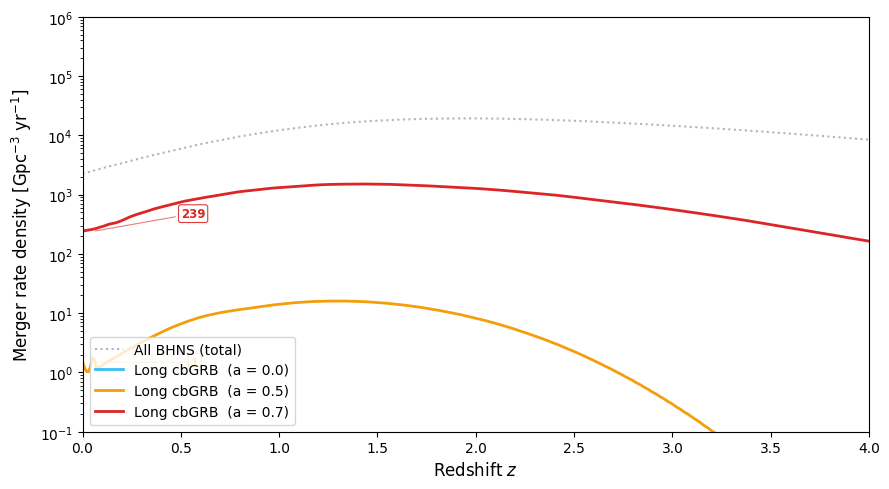

In [22]:
spin_colors = {0.0: '#38BDF8', 0.5: '#F59E0B', 0.7: '#DC2626'}
merger_rates_BHNS_spin = {}

for a in [0.0, 0.5, 0.7]:
    M_disk_a = foucart_disk_mass(BH, NS, a_BH=a)
    long_a   = (M_disk_a >= 0.1)
    print(f'a={a}: Long cbGRB = {long_a.sum():,}  ({100*long_a.mean():.1f}%)')
    rate = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BHNS, dPdlogZ, metallicities, p_draw,
        Z_BHNS[long_a], delay_BHNS[long_a], w_BHNS[long_a],
    )
    merger_rates_BHNS_spin[a] = rate
    print(f'  z=0: {rate[0]:.1f}  |  z=1: {rate[np.argmin(np.abs(redshifts-1))]:,.1f}  Gpc\u207b\u00b3 yr\u207b\u00b9')

# Per-spin annotation offsets to stagger labels and avoid overlap
annot_offsets = {0.0: (0.45, 0.82), 0.5: (0.55, 1.0), 0.7: (0.50, 2.0)}

fig, ax = plt.subplots(figsize=(9, 5))

# Gray dotted reference: total BHNS merger rate
ax.plot(redshifts, merger_rates_BHNS['All BHNS'],
        color='#94A3B8', lw=1.5, ls=':', alpha=0.8, label='All BHNS (total)')

# Spin curves with staggered z=0 annotations
for a, color in spin_colors.items():
    rate = merger_rates_BHNS_spin[a]
    ax.plot(redshifts, rate, color=color, lw=2, label=f'Long cbGRB  (a = {a})')
    z0_val = rate[0]
    if z0_val > 0:
        xt, ym = annot_offsets[a]
        ax.annotate(f'{z0_val:.0f}',
                    xy=(0.05, z0_val), xytext=(xt, z0_val * ym),
                    color=color, fontsize=8.5, fontweight='bold', va='center',
                    arrowprops=dict(arrowstyle='-', color=color, lw=0.8, alpha=0.6),
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                              edgecolor=color, alpha=0.9, lw=0.8))

ax.set_xlim(0, 4)
ax.set_ylim(1e-1, 1e6)
ax.set_yscale('log')
ax.set_xlabel('Redshift $z$', fontsize=12)
ax.set_ylabel(r'Merger rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=12)
ax.legend(fontsize=10, loc='lower left')
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/rate_bhns_spin_sensitivity.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 5b. BNS M_crit Sensitivity (EOS Uncertainty)

The critical total mass `M_crit = 2.8 M☉` separating HMNS-powered short cbGRBs from  
BH-disk systems is uncertain by ±0.2 M☉ depending on the neutron star equation of state.  
Vary from 2.6–3.0 M☉ to show the resulting uncertainty band on the short and long cbGRB rates.  
The solid black line is the fiducial value used throughout the analysis.

M_crit=2.6: Short=189,138 (81.1%)  Long=43,999 (18.9%)
M_crit=2.8: Short=189,855 (81.4%)  Long=43,282 (18.6%)
M_crit=3.0: Short=203,424 (87.3%)  Long=29,713 (12.7%)


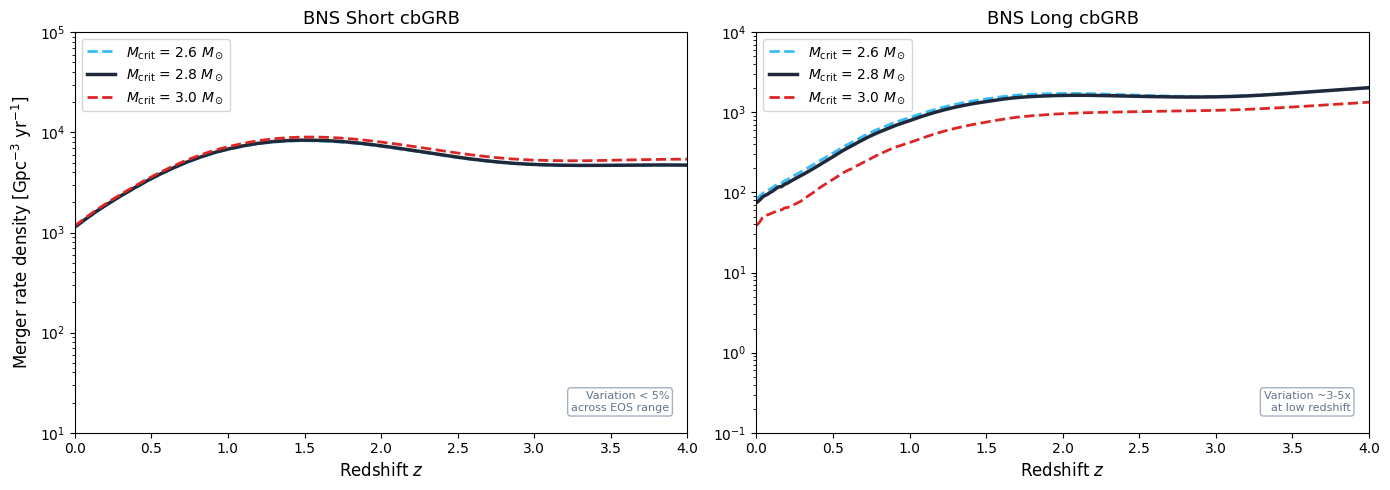

In [23]:
mcrit_colors = {2.6: '#38BDF8', 2.8: '#1E293B', 3.0: '#DC2626'}
mcrit_styles = {2.6: '--',         2.8: '-',      3.0: '--'}
rates_mcrit_short = {}
rates_mcrit_long  = {}

for Mc in [2.6, 2.8, 3.0]:
    s = (M_tot < Mc) | ((M_tot >= Mc) & (q < 1.2))
    l = (M_tot >= Mc) & (q >= 1.2)
    print(f'M_crit={Mc}: Short={s.sum():,} ({100*s.mean():.1f}%)  Long={l.sum():,} ({100*l.mean():.1f}%)')
    rates_mcrit_short[Mc] = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BNS, dPdlogZ, metallicities, p_draw,
        Z_BNS[s], delay_BNS[s], w_BNS[s],
    )
    rates_mcrit_long[Mc] = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BNS, dPdlogZ, metallicities, p_draw,
        Z_BNS[l], delay_BNS[l], w_BNS[l],
    )

# Independent y-axes so each panel uses its own data range
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for Mc in [2.6, 2.8, 3.0]:
    c, ls = mcrit_colors[Mc], mcrit_styles[Mc]
    lw = 2.5 if Mc == 2.8 else 2
    axes[0].plot(redshifts, rates_mcrit_short[Mc], color=c, ls=ls, lw=lw,
                 label=f'$M_{{\mathrm{{crit}}}}$ = {Mc} $M_\odot$')
    axes[1].plot(redshifts, rates_mcrit_long[Mc],  color=c, ls=ls, lw=lw,
                 label=f'$M_{{\mathrm{{crit}}}}$ = {Mc} $M_\odot$')

for ax, title, ylims in zip(axes,
                             ['Short cbGRB', 'Long cbGRB'],
                             [(1e1, 1e5),    (1e-1, 1e4)]):
    ax.set_xlim(0, 4)
    ax.set_ylim(*ylims)
    ax.set_yscale('log')
    ax.set_xlabel('Redshift $z$', fontsize=12)
    ax.set_title(f'BNS {title}', fontsize=13)
    ax.legend(fontsize=10, loc='upper left')
axes[0].set_ylabel(r'Merger rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=12)

# Robustness annotations -- bottom right of each panel
axes[0].text(0.97, 0.05, 'Variation < 5%\nacross EOS range',
             transform=axes[0].transAxes, fontsize=8, color='#64748B',
             ha='right', va='bottom',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                       edgecolor='#94A3B8', alpha=0.85))
axes[1].text(0.97, 0.05, 'Variation ~3-5x\nat low redshift',
             transform=axes[1].transAxes, fontsize=8, color='#64748B',
             ha='right', va='bottom',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                       edgecolor='#94A3B8', alpha=0.85))

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/rate_bns_mcrit_sensitivity.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 5c. Model K vs Model A: Binary Physics Uncertainty

Model K uses a lower common envelope efficiency (α_CE = 0.5) vs the fiducial Model A (α_CE = 1.0).  
Comparing the full cosmic rates between models shows how sensitive the predicted GRB rates are  
to uncertain binary evolution physics - independent of the EOS or BH spin assumptions.

Both short and long cbGRB rates are compared, with the shaded band showing the model uncertainty range.

Model K - Merging BNS: 234,963
Short cbGRB: 191,290  (81.4%)
Long  cbGRB: 43,673  (18.6%)
Computing Model K Short cbGRB (191,290 systems)...
  z=0: 1304.8  Gpc-3 yr-1
Computing Model K Long cbGRB (43,673 systems)...
  z=0: 200.6  Gpc-3 yr-1
Computing Model K All BNS (234,963 systems)...
  z=0: 1505.4  Gpc-3 yr-1


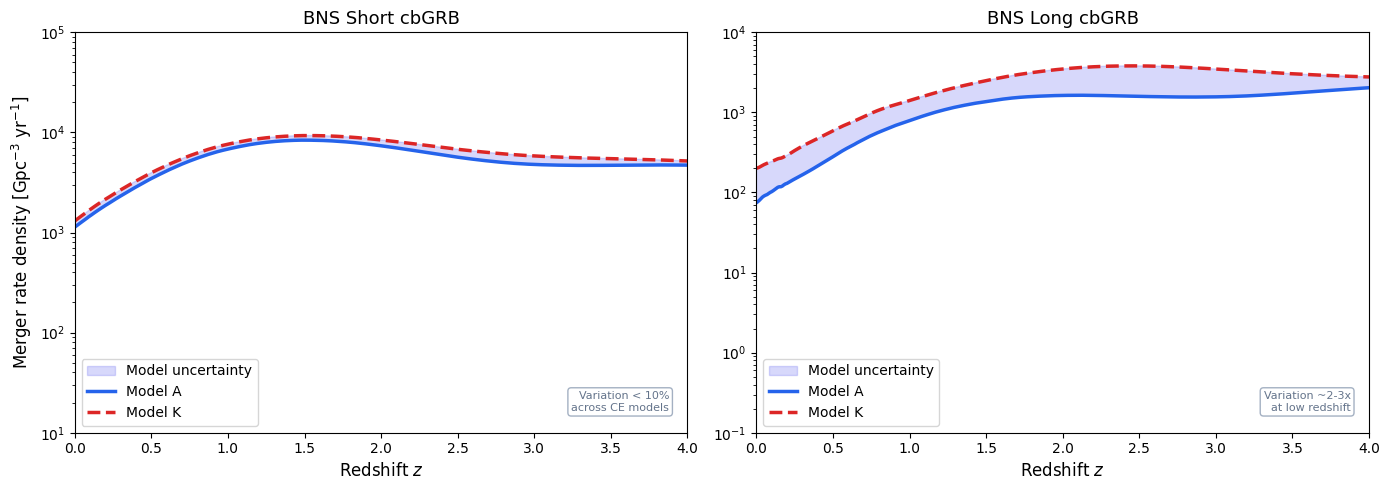

In [24]:
path_K = '/Users/josephrodriguez/research visualization/Data/COMPASCompactOutput_BNS_K.h5'
with h5.File(path_K, 'r') as f:
    fDCO = f['doubleCompactObjects']
    mass1_K   = fDCO['M1'][...].squeeze()
    mass2_K   = fDCO['M2'][...].squeeze()
    weights_K = fDCO['weight'][...].squeeze()
    Z_K_all   = fDCO['Metallicity1'][...].squeeze()
    merges_K  = fDCO['mergesInHubbleTimeFlag'][...].squeeze()
    tc_K      = fDCO['tc'][...].squeeze()
    tform_K   = fDCO['tform'][...].squeeze()

mask_K  = (merges_K == 1)
M_tot_K = mass1_K[mask_K] + mass2_K[mask_K]
q_K     = np.maximum(mass1_K[mask_K], mass2_K[mask_K]) / np.minimum(mass1_K[mask_K], mass2_K[mask_K])

short_K = (M_tot_K < 2.8) | ((M_tot_K >= 2.8) & (q_K < 1.2))
long_K  = (M_tot_K >= 2.8) & (q_K >= 1.2)

delay_K = (tform_K + tc_K)[mask_K]
Z_K     = Z_K_all[mask_K]
w_K     = weights_K[mask_K]

print(f'Model K - Merging BNS: {mask_K.sum():,}')
print(f'Short cbGRB: {short_K.sum():,}  ({100*short_K.mean():.1f}%)')
print(f'Long  cbGRB: {long_K.sum():,}  ({100*long_K.mean():.1f}%)')

merger_rates_K = {}
for label, mask_grb in [('Short cbGRB', short_K),
                          ('Long cbGRB',  long_K),
                          ('All BNS',     np.ones(len(delay_K), dtype=bool))]:
    print(f'Computing Model K {label} ({mask_grb.sum():,} systems)...')
    rate = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BNS, dPdlogZ, metallicities, p_draw,
        Z_K[mask_grb], delay_K[mask_grb], w_K[mask_grb],
    )
    merger_rates_K[label] = rate
    print(f'  z=0: {rate[0]:.1f}  Gpc-3 yr-1')

# ---- Plot Model A vs Model K ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, label in zip([ax1, ax2], ['Short cbGRB', 'Long cbGRB']):
    rA = merger_rates_BNS[label]
    rK = merger_rates_K[label]
    # Uncertainty band beneath lines
    ax.fill_between(redshifts,
                    np.minimum(rA, rK), np.maximum(rA, rK),
                    alpha=0.25, color='#6366F1', label='Model uncertainty')
    ax.plot(redshifts, rA, color='#2563EB', lw=2.5, label='Model A')
    ax.plot(redshifts, rK, color='#DC2626',  lw=2.5, ls='--', label='Model K')
    ax.set_xlim(0, 4)
    ax.set_yscale('log')
    ax.set_xlabel('Redshift $z$', fontsize=12)
    ax.set_title(f'BNS {label}', fontsize=13)
    ax.legend(fontsize=10, loc='lower left')
    pass  # annotations set per-panel below

# Per-panel annotations (short: robust; long: sensitive to CE efficiency)
ax1.text(0.97, 0.05, 'Variation < 10%\nacross CE models',
         transform=ax1.transAxes, fontsize=8, color='#64748B',
         ha='right', va='bottom',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                   edgecolor='#94A3B8', alpha=0.85))
ax2.text(0.97, 0.05, 'Variation ~2-3x\nat low redshift',
         transform=ax2.transAxes, fontsize=8, color='#64748B',
         ha='right', va='bottom',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                   edgecolor='#94A3B8', alpha=0.85))

# Set ylim AFTER all plotting to prevent autoscale override
ax1.set_ylim(1e1, 1e5)
ax2.set_ylim(1e-1, 1e4)

ax1.set_ylabel(r'Merger rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=12)
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/rate_bns_model_ak.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 8. Combined BNS + BHNS Plot

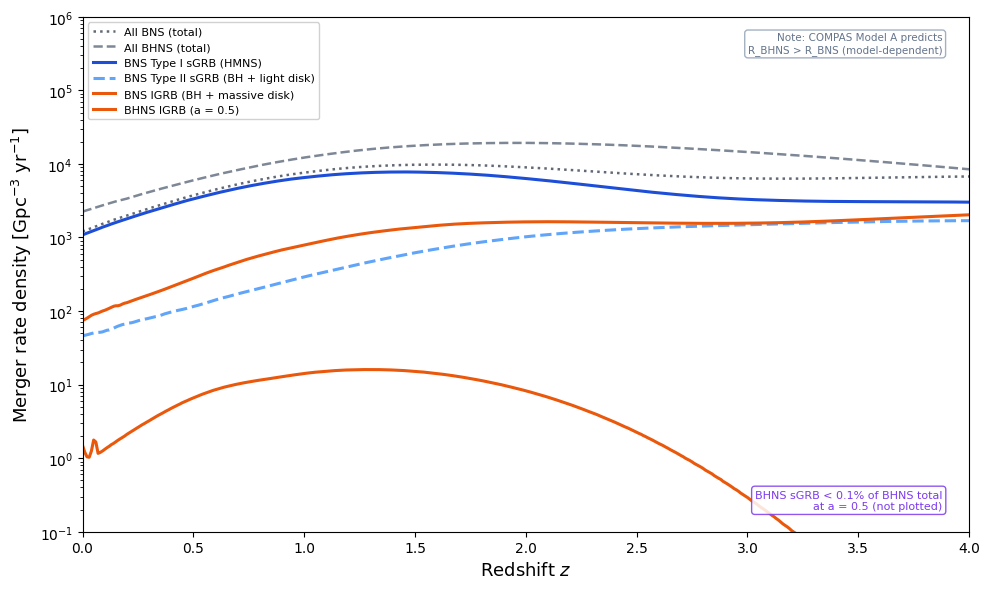

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))

# ---- Totals (black, background reference) ----
ax.plot(redshifts, merger_rates_BNS['All BNS'],
        color='#1E293B', lw=1.8, ls=':', alpha=0.7, label='All BNS (total)')
ax.plot(redshifts, merger_rates_BHNS['All BHNS'],
        color='#475569', lw=1.8, ls='--', alpha=0.7, label='All BHNS (total)')

# ---- BNS channels ----
ax.plot(redshifts, merger_rates_BNS['Short cbGRB (Type I)'],
        color='#1D4ED8', lw=2.2, ls='-',
        label=r'BNS Type I sGRB (HMNS)')
ax.plot(redshifts, merger_rates_BNS['Short cbGRB (Type II)'],
        color='#60A5FA', lw=2.2, ls='--',
        label=r'BNS Type II sGRB (BH + light disk)')
ax.plot(redshifts, merger_rates_BNS['Long cbGRB'],
        color='#EA580C', lw=2.2, ls='-',
        label=r'BNS lGRB (BH + massive disk)')

# ---- BHNS channels (a=0.5) ----
ax.plot(redshifts, merger_rates_BHNS['Long cbGRB (a=0.5)'],
        color='#EA580C', lw=2.2, ls='-',
        label=r'BHNS lGRB (a = 0.5)')

# Legend -- upper left, reduced font to avoid clipping
ax.legend(fontsize=8, loc='upper left', framealpha=0.9)

# Standalone annotation for suppressed BHNS sGRB channel
ax.text(0.97, 0.04,
        'BHNS sGRB < 0.1% of BHNS total\nat a = 0.5 (not plotted)',
        transform=ax.transAxes, fontsize=8, color='#7C3AED',
        va='bottom', ha='right',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='#7C3AED', alpha=0.85))

# Flag if BHNS total exceeds BNS total at z=0 -- model-dependent result
if merger_rates_BHNS['All BHNS'][0] > merger_rates_BNS['All BNS'][0]:
    ax.text(0.97, 0.97,
            'Note: COMPAS Model A predicts\nR_BHNS > R_BNS (model-dependent)',
            transform=ax.transAxes, fontsize=7.5, color='#64748B',
            va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#94A3B8', alpha=0.85))

ax.set_xlim(0, 4)
ax.set_ylim(1e-1, 1e6)
ax.set_yscale('log')
ax.set_xlabel('Redshift $z$', fontsize=13)
ax.set_ylabel(r'Merger rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=13)
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/rate_combined_bns_bhns.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 9. Unified Figure 2 Rate Plot: All cbGRB Classes

Full Gottlieb et al. (2023) Figure 2 classification across cosmic time.
All five physically distinct outcomes are shown on a single axis:
- **BNS Type I sGRB** (HMNS-powered): M_tot < M_crit
- **BNS Type II sGRB** (BH + light disk): M_tot >= M_crit, q < 1.2
- **BNS lGRB** (BH + massive disk): M_tot >= M_crit, q >= 1.2
- **BHNS sGRB** (small disk, Foucart a=0.5): 0 < M_disk < 0.1 M_sun
- **BHNS lGRB** (massive disk, Foucart a=0.5): M_disk >= 0.1 M_sun

BHNS sGRB  z=0: 480.535  Gpc-3 yr-1
BHNS lGRB  z=0: 1.487  Gpc-3 yr-1
BHNS total z=0: 2246.644  Gpc-3 yr-1
BHNS sGRB fraction of total at z=0: 0.2139


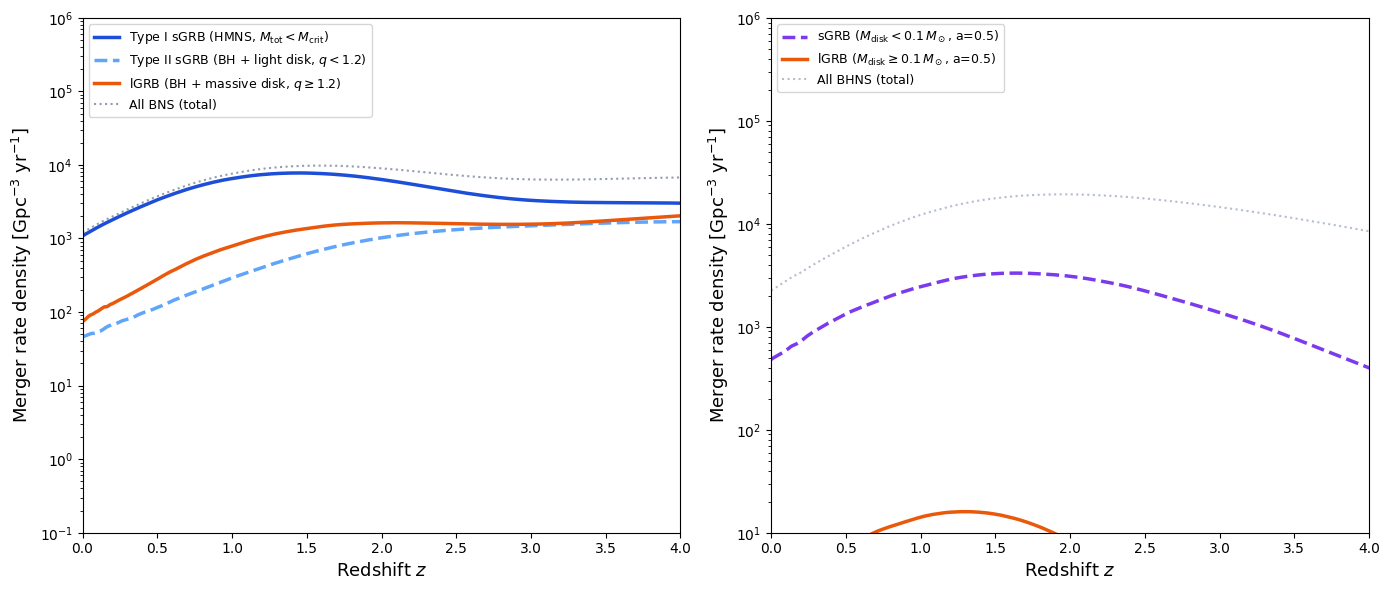

In [26]:
# Diagnostic: check BHNS sGRB vs total at z=0 to see if the channel is negligible
bhns_sgrb_arr  = merger_rates_BHNS['Short cbGRB (a=0.5)']
bhns_lgrb_arr  = merger_rates_BHNS['Long cbGRB (a=0.5)']
bhns_total_arr = merger_rates_BHNS['All BHNS']
print(f"BHNS sGRB  z=0: {bhns_sgrb_arr[0]:.3f}  Gpc-3 yr-1")
print(f"BHNS lGRB  z=0: {bhns_lgrb_arr[0]:.3f}  Gpc-3 yr-1")
print(f"BHNS total z=0: {bhns_total_arr[0]:.3f}  Gpc-3 yr-1")
sgrb_frac = bhns_sgrb_arr[0] / bhns_total_arr[0] if bhns_total_arr[0] > 0 else 0.0
print(f"BHNS sGRB fraction of total at z=0: {sgrb_frac:.4f}")

fig, (ax_bns, ax_bhns) = plt.subplots(1, 2, figsize=(14, 6))

# ---- Left panel: BNS channels ----
ax_bns.plot(redshifts, merger_rates_BNS['Short cbGRB (Type I)'],
            color='#1D4ED8', lw=2.5, ls='-',
            label=r'Type I sGRB (HMNS, $M_\mathrm{tot} < M_\mathrm{crit}$)')
ax_bns.plot(redshifts, merger_rates_BNS['Short cbGRB (Type II)'],
            color='#60A5FA', lw=2.5, ls='--',
            label=r'Type II sGRB (BH + light disk, $q < 1.2$)')
ax_bns.plot(redshifts, merger_rates_BNS['Long cbGRB'],
            color='#EA580C', lw=2.5, ls='-',
            label=r'lGRB (BH + massive disk, $q \geq 1.2$)')
ax_bns.plot(redshifts, merger_rates_BNS['All BNS'],
            color='#64748B', lw=1.5, ls=':', alpha=0.7, label='All BNS (total)')
ax_bns.set_xlim(0, 4)
ax_bns.set_ylim(1e-1, 1e6)
ax_bns.set_yscale('log')
ax_bns.set_xlabel('Redshift $z$', fontsize=13)
ax_bns.set_ylabel(r'Merger rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=13)
ax_bns.legend(fontsize=9, loc='upper left')

# ---- Right panel: BHNS channels (a=0.5 fiducial) ----
# Only show the sGRB line if it is non-negligible (>5% of total); otherwise note in panel
if sgrb_frac > 0.05:
    ax_bhns.plot(redshifts, bhns_sgrb_arr,
                 color='#7C3AED', lw=2.5, ls='--',
                 label=r'sGRB ($M_\mathrm{disk} < 0.1\,M_\odot$, a=0.5)')
ax_bhns.plot(redshifts, bhns_lgrb_arr,
             color='#EA580C', lw=2.5, ls='-',
             label=r'lGRB ($M_\mathrm{disk} \geq 0.1\,M_\odot$, a=0.5)')
ax_bhns.plot(redshifts, bhns_total_arr,
             color='#94A3B8', lw=1.5, ls=':', alpha=0.7, label='All BHNS (total)')

# Annotate if sGRB channel is negligible
if sgrb_frac <= 0.05:
    ax_bhns.text(0.97, 0.97,
                 f'sGRB channel < {sgrb_frac*100:.1f}% of total\n(not plotted)',
                 transform=ax_bhns.transAxes, fontsize=8, color='#7C3AED',
                 ha='right', va='top',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                           edgecolor='#7C3AED', alpha=0.8))

ax_bhns.set_xlim(0, 4)
ax_bhns.set_ylim(1e1, 1e6)
ax_bhns.set_yscale('log')
ax_bhns.set_xlabel('Redshift $z$', fontsize=13)
ax_bhns.set_ylabel(r'Merger rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=13)
ax_bhns.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/rate_figure2_unified.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 10. Mass Distributions at Redshift Slices

How does the merging BNS mass distribution shift with cosmic time? At high redshift
low-metallicity star formation dominates, which can change the typical NS mass and
shift the long vs short cbGRB balance. Here each binary is weighted by its
contribution to the merger rate at a specific target redshift.

In [27]:
def per_system_rate_weights(z_target, redshifts, times, time_first_SF,
                             n_formed, dPdlogZ, metallicities, p_draw,
                             COMPAS_Z, COMPAS_delay_times, COMPAS_weights):
    """
    Per-system contribution to the merger rate at z_target.
    Mirrors compute_merger_rate but returns an array of individual weights
    instead of summing them, so histograms can be weighted by rate contribution.
    """
    redshift_step = redshifts[1] - redshifts[0]
    times_to_z    = interp1d(times, redshifts)

    j_target = np.argmin(np.abs(redshifts - z_target))
    t_merge  = times[j_target]

    Z_bins = np.clip(np.digitize(COMPAS_Z, metallicities), 0, len(metallicities) - 1)
    t_min  = max(time_first_SF, times.min())

    out    = np.zeros(len(COMPAS_weights))
    t_form = t_merge - COMPAS_delay_times
    valid  = t_form >= t_min

    if valid.any():
        z_form     = times_to_z(t_form[valid])
        z_form_idx = np.clip(np.ceil(z_form / redshift_step).astype(int),
                             0, len(redshifts) - 1)
        out[valid] = (n_formed[z_form_idx]
                      * dPdlogZ[z_form_idx, Z_bins[valid]]
                      / p_draw
                      * COMPAS_weights[valid])
    return out


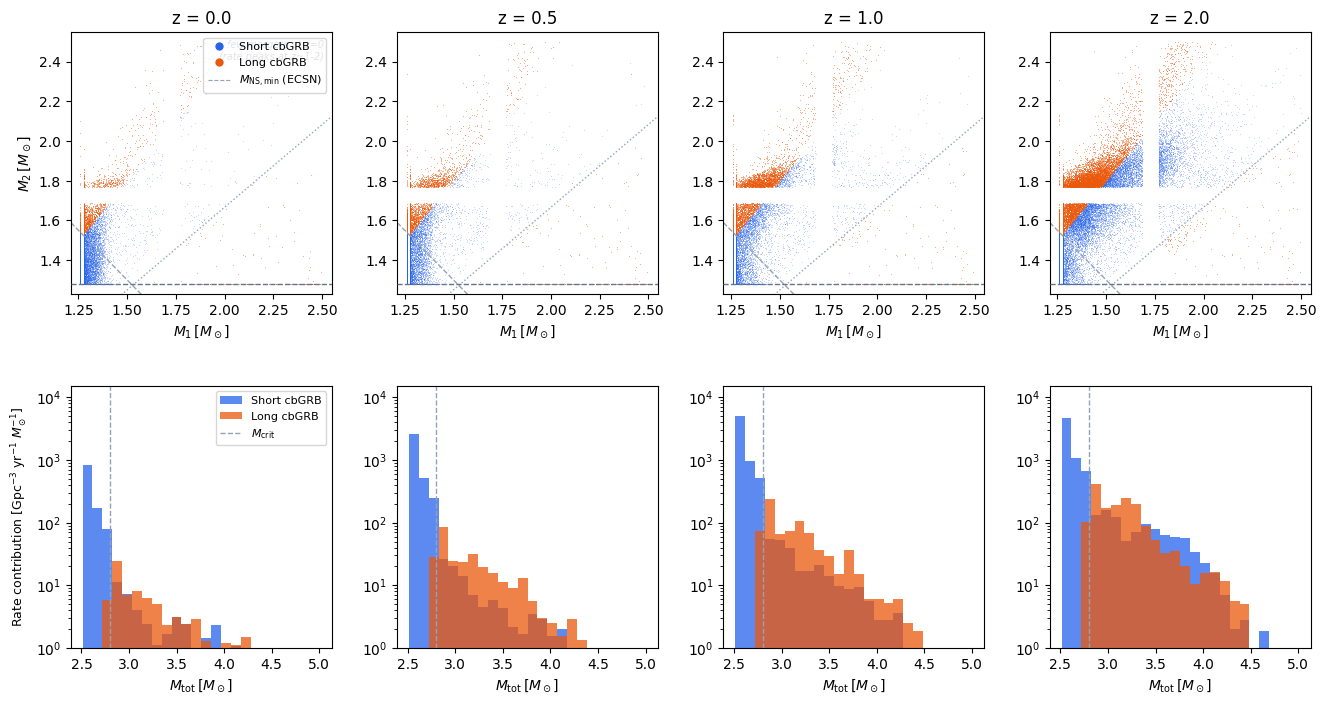

In [28]:
M1_m = mass1[mask_BNS]
M2_m = mass2[mask_BNS]

z_slices = [0.0, 0.5, 1.0, 2.0]

# Fixed axes from full catalogue so all panels are directly comparable
_m1_pad = 0.04 * (M1_m.max() - M1_m.min())
_m2_pad = 0.04 * (M2_m.max() - M2_m.min())
m1_xlim  = (M1_m.min() - _m1_pad, M1_m.max() + _m1_pad)
m2_ylim  = (M2_m.min() - _m2_pad, M2_m.max() + _m2_pad)
bins_mtot = np.linspace(M_tot.min() * 0.99, M_tot.max() * 1.01, 25)

fig, axes = plt.subplots(2, 4, figsize=(16, 8),
                         gridspec_kw={'hspace': 0.35, 'wspace': 0.25})

_hist_ymaxes = []

for col, z_s in enumerate(z_slices):
    w = per_system_rate_weights(
        z_s, redshifts, times, time_first_SF,
        n_formed_BNS, dPdlogZ, metallicities, p_draw,
        Z_BNS, delay_BNS, w_BNS,
    )

    # --- Top row: M1 vs M2 scatter (top 40% rate contributors) ---
    ax = axes[0, col]
    w_thresh = np.percentile(w[w > 0], 60) if (w > 0).any() else 0.0
    vis = w >= w_thresh

    ax.scatter(M1_m[vis & short_BNS], M2_m[vis & short_BNS],
               s=0.3, c='#2563EB', alpha=0.30, linewidths=0, zorder=1)
    ax.scatter(M1_m[vis & long_BNS],  M2_m[vis & long_BNS],
               s=0.3, c='#EA580C', alpha=0.60, linewidths=0, zorder=2)

    # Classification lines clipped to fixed axis range
    m_vals = np.linspace(m1_xlim[0], m1_xlim[1], 200)
    ax.plot(m_vals, 2.8 - m_vals, color='#94A3B8', lw=1, ls='--')   # M_tot = 2.8
    ax.plot(m_vals, m_vals / 1.2,  color='#94A3B8', lw=1, ls=':')   # q = 1.2
    ecsn_mass = M2_m.min()
    ax.axhline(ecsn_mass, color='#64748B', lw=1.0, ls='--', zorder=3)

    ax.set_xlim(*m1_xlim)
    ax.set_ylim(*m2_ylim)
    ax.set_title(f'z = {z_s}', fontsize=12)
    if z_s == 0.0:
        ax.text(0.97, 0.97, 'few mergers at z=0\n(rate peaks at z~1-2)',
                transform=ax.transAxes, fontsize=7, color='#64748B',
                ha='right', va='top', style='italic')
    ax.set_xlabel(r'$M_1\,[M_\odot]$', fontsize=10)
    if col == 0:
        ax.set_ylabel(r'$M_2\,[M_\odot]$', fontsize=10)
        from matplotlib.lines import Line2D
        ax.legend(handles=[
            Line2D([0],[0], marker='o', color='w', markerfacecolor='#2563EB',
                   markersize=7, label='Short cbGRB'),
            Line2D([0],[0], marker='o', color='w', markerfacecolor='#EA580C',
                   markersize=7, label='Long cbGRB'),
            Line2D([0],[0], color='#94A3B8', lw=0.8, ls='--',
                   label=r'$M_\mathrm{NS,min}$ (ECSN)'),
        ], fontsize=8)

    # --- Bottom row: M_tot histogram ---
    ax2 = axes[1, col]
    n_sh, *_ = ax2.hist(M_tot[short_BNS], bins=bins_mtot, weights=w[short_BNS],
                         color='#2563EB', alpha=0.75, label='Short cbGRB')
    n_ln, *_ = ax2.hist(M_tot[long_BNS],  bins=bins_mtot, weights=w[long_BNS],
                         color='#EA580C', alpha=0.75, label='Long cbGRB')
    _hist_ymaxes.append(max(n_sh.max(), n_ln.max()))
    ax2.axvline(2.8, color='#94A3B8', ls='--', lw=1, label=r'$M_\mathrm{crit}$')
    ax2.set_yscale('log')
    ax2.set_xlabel(r'$M_\mathrm{tot}\,[M_\odot]$', fontsize=10)
    if col == 0:
        ax2.set_ylabel(r'Rate contribution [Gpc$^{-3}$ yr$^{-1}$ $M_\odot^{-1}$]',
                       fontsize=9)
        ax2.legend(fontsize=8)

# Shared log y-axis on bottom row
_ymax = max(_hist_ymaxes) * 3
_ymin = 1.0  # floor below which noise is meaningless
for ax2 in axes[1]:
    ax2.set_ylim(_ymin, _ymax)

plt.savefig('/Users/josephrodriguez/research visualization/plots/bns_mass_dist_redshift_slices.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 10b. BNS Gottlieb Classification Plane: q vs M_tot at Redshift Slices

Recreates the Gottlieb et al. (2023) Fig. 2 classification diagram using the COMPAS population,
weighted by rate contribution at each redshift. Shows how the three BNS outcomes, Short Type I
(HMNS), Short Type II (BH + light disk), Long cbGRB (BH + massive disk), populate the
$q$–$M_\mathrm{tot}$ plane and how the dominant outcome shifts with cosmic time.

/var/folders/2v/8vp9x9fx2lb37s50qxbd6gy00000gn/T/ipykernel_16038/1497619180.py:142: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


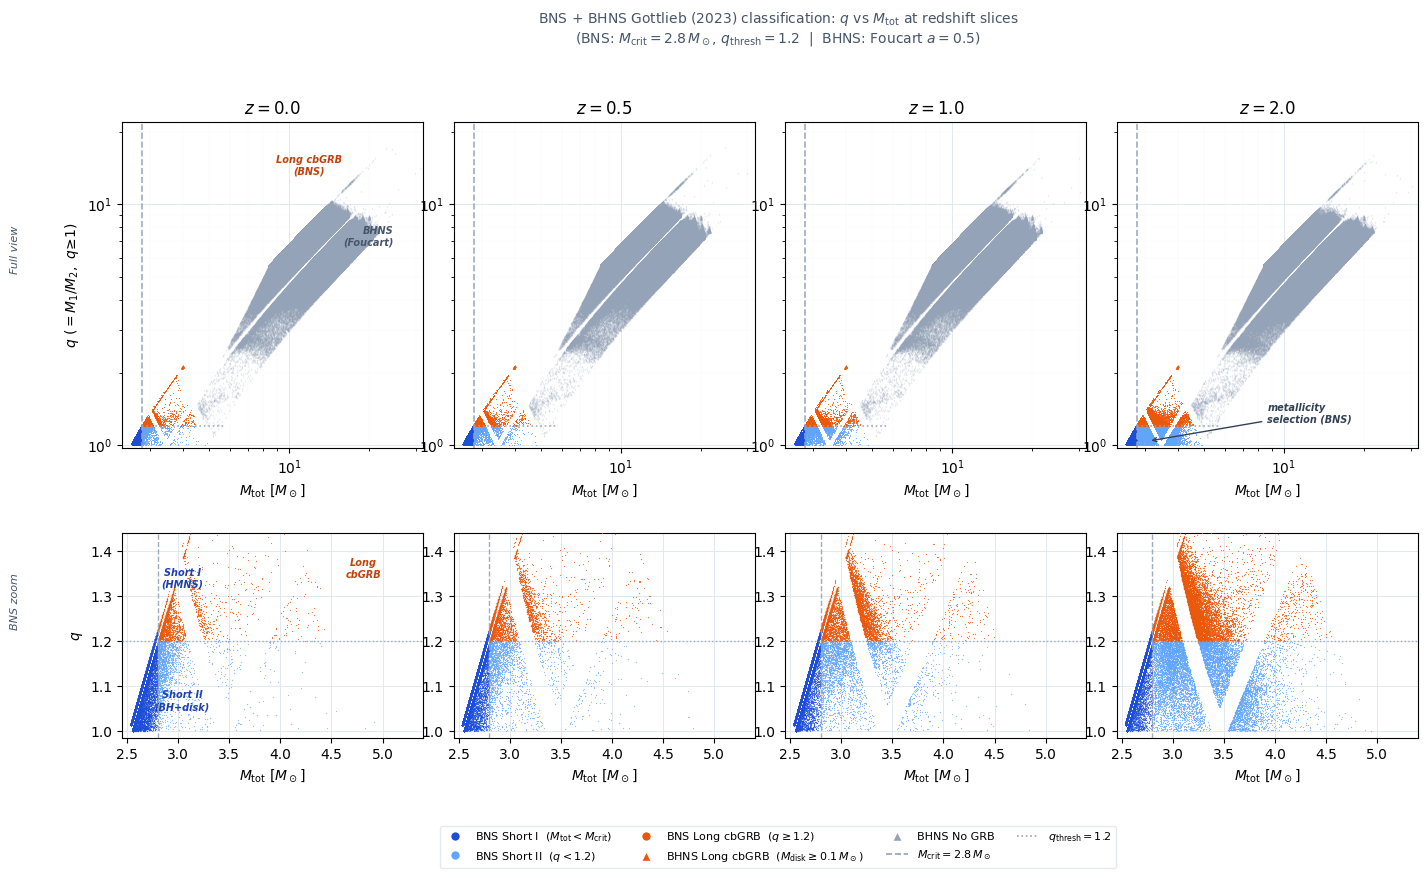

In [29]:
from matplotlib.lines import Line2D

M_crit   = 2.8
q_thresh = 1.2
z_slices = [0.0, 0.5, 1.0, 2.0]

q_BHNS     = BH / NS
M_tot_BHNS = BH + NS

# Axis limits
mt_xlim  = (2.35, 32)       # full view (log)
q_ylim   = (0.97, 22)
bns_xlim = (2.45, 5.4)      # BNS zoom (linear)
bns_ylim = (0.985, 1.44)
_bns_mt_max = 5.8

fig, axes = plt.subplots(2, 4, figsize=(16, 8),
                          gridspec_kw={'hspace': 0.32, 'wspace': 0.10,
                                       'height_ratios': [1.6, 1]})
fig.suptitle(r'BNS + BHNS Gottlieb (2023) classification: $q$ vs $M_\mathrm{tot}$ at redshift slices'
             '\n'
             r'(BNS: $M_\mathrm{crit}=2.8\,M_\odot$, $q_\mathrm{thresh}=1.2$  |  BHNS: Foucart $a=0.5$)',
             fontsize=10, color='#475569', y=1.02)

for col, z_s in enumerate(z_slices):

    # ── rate weights ──────────────────────────────────────────────────────
    w_bns = per_system_rate_weights(
        z_s, redshifts, times, time_first_SF,
        n_formed_BNS, dPdlogZ, metallicities, p_draw,
        Z_BNS, delay_BNS, w_BNS,
    )
    w_bhns = per_system_rate_weights(
        z_s, redshifts, times, time_first_SF,
        n_formed_BHNS, dPdlogZ, metallicities, p_draw,
        Z_BHNS, delay_BHNS, w_BHNS,
    )
    w_t_bns  = np.percentile(w_bns[w_bns > 0],   60) if (w_bns  > 0).any() else 0.0
    w_t_bhns = np.percentile(w_bhns[w_bhns > 0], 60) if (w_bhns > 0).any() else 0.0
    vis_bns  = w_bns  >= w_t_bns
    vis_bhns = w_bhns >= w_t_bhns

    # ── TOP ROW: full BNS + BHNS view (log scale) ─────────────────────────
    ax = axes[0, col]
    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.axvline(M_crit, color='#94A3B8', lw=1.2, ls='--', zorder=4, alpha=0.9)
    ax.plot([M_crit, _bns_mt_max], [q_thresh, q_thresh],
            color='#94A3B8', lw=1.2, ls=':', zorder=4, alpha=0.9)

    ax.scatter(M_tot[vis_bns & short_BNS_I],  q[vis_bns & short_BNS_I],
               s=0.5, c='#1D4ED8', alpha=0.60, linewidths=0, zorder=2, marker='o')
    ax.scatter(M_tot[vis_bns & short_BNS_II], q[vis_bns & short_BNS_II],
               s=0.5, c='#60A5FA', alpha=0.70, linewidths=0, zorder=2, marker='o')
    ax.scatter(M_tot[vis_bns & long_BNS],     q[vis_bns & long_BNS],
               s=0.5, c='#EA580C', alpha=0.80, linewidths=0, zorder=3, marker='o')
    ax.scatter(M_tot_BHNS[vis_bhns & no_BHNS],   q_BHNS[vis_bhns & no_BHNS],
               s=2.0, c='#94A3B8', alpha=0.25, linewidths=0, zorder=2, marker='^')
    ax.scatter(M_tot_BHNS[vis_bhns & long_BHNS],  q_BHNS[vis_bhns & long_BHNS],
               s=2.0, c='#EA580C', alpha=0.60, linewidths=0, zorder=3, marker='^')

    ax.grid(which='major', color='#E2E8F0', lw=0.7, ls='-', zorder=1)
    ax.grid(which='minor', color='#F8FAFC', lw=0.3, ls='-', zorder=1)
    ax.set_axisbelow(True)
    ax.set_xlim(*mt_xlim)
    ax.set_ylim(*q_ylim)
    ax.set_title(f'$z = {z_s}$', fontsize=12)
    ax.set_xlabel(r'$M_\mathrm{tot}\ [M_\odot]$', fontsize=10)
    if col == 0:
        ax.set_ylabel(r'$q\ (= M_1/M_2,\ q\!\geq\!1)$', fontsize=10)
        ax.text(0.62, 0.90, 'Long cbGRB\n(BNS)', transform=ax.transAxes,
                fontsize=7, color='#C2410C', ha='center', va='top',
                style='italic', fontweight='bold')
        ax.text(0.90, 0.65, 'BHNS\n(Foucart)', transform=ax.transAxes,
                fontsize=7, color='#475569', ha='right', va='center',
                style='italic', fontweight='bold')

    # Metallicity annotation on z=2.0 top panel
    if col == 3:
        ax.annotate('metallicity\nselection (BNS)',
                    xy=(3.1, 1.04), xycoords='data',
                    xytext=(0.50, 0.08), textcoords='axes fraction',
                    fontsize=7, color='#334155', style='italic', fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='#334155', lw=1.0))

    # ── BOTTOM ROW: BNS zoom (linear scale) ───────────────────────────────
    ax2 = axes[1, col]

    ax2.axvline(M_crit,   color='#94A3B8', lw=1.0, ls='--', zorder=4, alpha=0.9)
    ax2.axhline(q_thresh, color='#94A3B8', lw=1.0, ls=':', zorder=4, alpha=0.9)

    ax2.scatter(M_tot[vis_bns & short_BNS_I],  q[vis_bns & short_BNS_I],
                s=0.8, c='#1D4ED8', alpha=0.60, linewidths=0, zorder=2)
    ax2.scatter(M_tot[vis_bns & short_BNS_II], q[vis_bns & short_BNS_II],
                s=0.8, c='#60A5FA', alpha=0.70, linewidths=0, zorder=2)
    ax2.scatter(M_tot[vis_bns & long_BNS],     q[vis_bns & long_BNS],
                s=0.8, c='#EA580C', alpha=0.80, linewidths=0, zorder=3)

    ax2.grid(which='major', color='#E2E8F0', lw=0.7, ls='-', zorder=1)
    ax2.set_axisbelow(True)
    ax2.set_xlim(*bns_xlim)
    ax2.set_ylim(*bns_ylim)
    ax2.set_xlabel(r'$M_\mathrm{tot}\ [M_\odot]$', fontsize=10)
    if col == 0:
        ax2.set_ylabel(r'$q$', fontsize=10)
        ax2.text(0.20, 0.78, 'Short I\n(HMNS)', transform=ax2.transAxes,
                 fontsize=7, color='#1E40AF', ha='center', va='center',
                 style='italic', fontweight='bold')
        ax2.text(0.20, 0.18, 'Short II\n(BH+disk)', transform=ax2.transAxes,
                 fontsize=7, color='#1E40AF', ha='center', va='center',
                 style='italic', fontweight='bold')
        ax2.text(0.80, 0.88, 'Long\ncbGRB', transform=ax2.transAxes,
                 fontsize=7, color='#C2410C', ha='center', va='top',
                 style='italic', fontweight='bold')

# Row labels via fig.text — placed at a fixed left margin, vertically centred on each row
fig.text(0.02, 0.72, 'Full view', fontsize=8, color='#475569',
         ha='left', va='center', style='italic', rotation=90)
fig.text(0.02, 0.28, 'BNS zoom', fontsize=8, color='#475569',
         ha='left', va='center', style='italic', rotation=90)

# Shared legend below figure
legend_handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#1D4ED8',
           markersize=7, label=r'BNS Short I  ($M_\mathrm{tot} < M_\mathrm{crit}$)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#60A5FA',
           markersize=7, label=r'BNS Short II  ($q < 1.2$)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#EA580C',
           markersize=7, label=r'BNS Long cbGRB  ($q \geq 1.2$)'),
    Line2D([0],[0], marker='^', color='w', markerfacecolor='#EA580C',
           markersize=7, label=r'BHNS Long cbGRB  ($M_\mathrm{disk} \geq 0.1\,M_\odot$)'),
    Line2D([0],[0], marker='^', color='w', markerfacecolor='#94A3B8',
           markersize=7, label='BHNS No GRB'),
    Line2D([0],[0], color='#94A3B8', lw=1.2, ls='--', label=r'$M_\mathrm{crit} = 2.8\,M_\odot$'),
    Line2D([0],[0], color='#94A3B8', lw=1.2, ls=':', label=r'$q_\mathrm{thresh} = 1.2$'),
]
fig.legend(handles=legend_handles, fontsize=8, ncol=4,
           loc='lower center', bbox_to_anchor=(0.5, -0.06),
           framealpha=0.9, edgecolor='#E2E8F0')

plt.tight_layout()
plt.subplots_adjust(left=0.09)   # room for fig.text row labels
plt.savefig('/Users/josephrodriguez/research visualization/plots/bns_bhns_gottlieb_plane_redshift_slices.png',
            dpi=150, bbox_inches='tight')
plt.show()

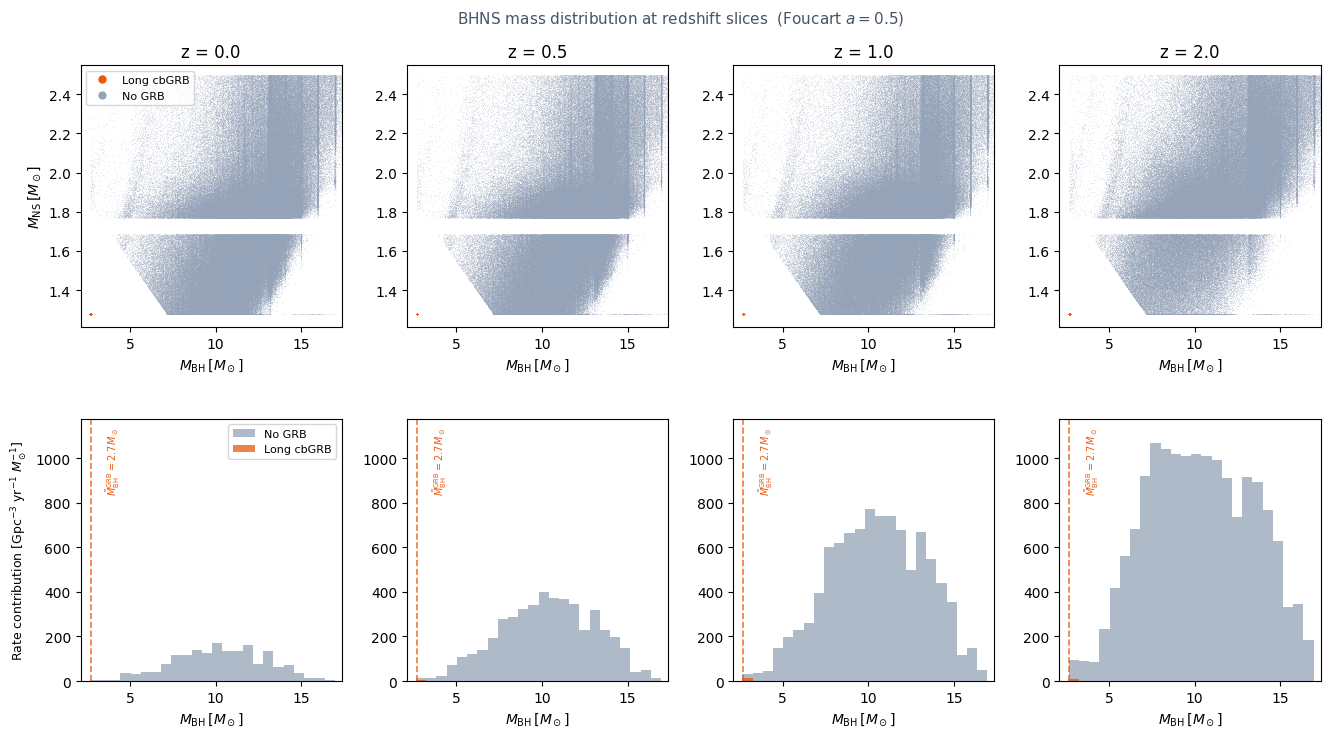

In [30]:
# ── BHNS Mass Distribution at Redshift Slices ────────────────────────────
z_slices = [0.0, 0.5, 1.0, 2.0]

# x-axis: clip to 99th percentile to remove sparse high-M_BH tail
_bh_max  = np.percentile(BH, 99)
_bh_pad  = 0.04 * (_bh_max - BH.min())
_ns_pad  = 0.04 * (NS.max() - NS.min())
bh_xlim  = (BH.min() - _bh_pad, _bh_max + _bh_pad)
ns_ylim  = (NS.min() - _ns_pad, NS.max() + _ns_pad)
bins_mbh = np.linspace(BH.min() * 0.99, _bh_max * 1.01, 25)

# Median BH mass of GRB-capable systems — threshold annotation on histograms
mbh_grb_median = np.median(BH[long_BHNS])

fig, axes = plt.subplots(2, 4, figsize=(16, 8),
                         gridspec_kw={'hspace': 0.35, 'wspace': 0.25})
fig.suptitle(r'BHNS mass distribution at redshift slices  (Foucart $a = 0.5$)',
             fontsize=11, color='#475569', y=0.95)

# Collect histogram y-maxima to set a shared y-limit after plotting
_hist_ymaxes = []

for col, z_s in enumerate(z_slices):
    w = per_system_rate_weights(
        z_s, redshifts, times, time_first_SF,
        n_formed_BHNS, dPdlogZ, metallicities, p_draw,
        Z_BHNS, delay_BHNS, w_BHNS,
    )

    # --- Top row: M_BH vs M_NS scatter ---
    ax = axes[0, col]
    w_thresh = np.percentile(w[w > 0], 60) if (w > 0).any() else 0.0
    vis = w >= w_thresh

    ax.scatter(BH[vis & no_BHNS],   NS[vis & no_BHNS],
               s=0.3, c='#94A3B8', alpha=0.20, linewidths=0, zorder=1)
    ax.scatter(BH[vis & long_BHNS], NS[vis & long_BHNS],
               s=1.0, c='#EA580C', alpha=0.80, linewidths=0, zorder=2)

    ax.set_xlim(*bh_xlim)
    ax.set_ylim(*ns_ylim)
    ax.set_title(f'z = {z_s}', fontsize=12)
    ax.set_xlabel(r'$M_\mathrm{BH}\,[M_\odot]$', fontsize=10)
    if col == 0:
        ax.set_ylabel(r'$M_\mathrm{NS}\,[M_\odot]$', fontsize=10)
        from matplotlib.lines import Line2D
        ax.legend(handles=[
            Line2D([0],[0], marker='o', color='w', markerfacecolor='#EA580C',
                   markersize=7, label='Long cbGRB'),
            Line2D([0],[0], marker='o', color='w', markerfacecolor='#94A3B8',
                   markersize=7, label='No GRB'),
        ], fontsize=8)

    # --- Bottom row: M_BH histogram ---
    ax2 = axes[1, col]
    n_no,  *_ = ax2.hist(BH[no_BHNS],   bins=bins_mbh, weights=w[no_BHNS],
                          color='#94A3B8', alpha=0.75, label='No GRB')
    n_lng, *_ = ax2.hist(BH[long_BHNS], bins=bins_mbh, weights=w[long_BHNS],
                          color='#EA580C', alpha=0.75, label='Long cbGRB')
    _hist_ymaxes.append(max(n_no.max(), n_lng.max()))

    # Median GRB-capable M_BH threshold
    ax2.axvline(mbh_grb_median, color='#EA580C', lw=1.2, ls='--', alpha=0.8)
    ax2.text(mbh_grb_median + 0.8, 0.97,
             f'$\\tilde{{M}}_{{\\rm BH}}^{{\\rm GRB}}={mbh_grb_median:.1f}\\,M_\\odot$',
             fontsize=7, color='#EA580C', va='top', rotation=90,
             transform=ax2.get_xaxis_transform())

    ax2.set_xlim(*bh_xlim)
    ax2.set_ylim(bottom=0)
    ax2.set_xlabel(r'$M_\mathrm{BH}\,[M_\odot]$', fontsize=10)
    if col == 0:
        ax2.set_ylabel(
            r'Rate contribution [Gpc$^{-3}$ yr$^{-1}$ $M_\odot^{-1}$]',
            fontsize=9)
        ax2.legend(fontsize=8)

# Shared y-axis on bottom row
_ymax = max(_hist_ymaxes) * 1.1
for ax2 in axes[1]:
    ax2.set_ylim(0, _ymax)

plt.savefig('/Users/josephrodriguez/research visualization/plots/bhns_mass_dist_redshift_slices.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 11. BNS vs BHNS Dominance vs Redshift

What fraction of long (and short) cbGRBs come from BNS vs BHNS as a function of redshift?
This directly answers which compact binary channel dominates the observable GRB population at each epoch.

**Beaming:** Fiducial $f_b = 1/200$ ($\theta_{\rm jet} \approx 5.7°$; Fong et al. 2015, Berger 2014), with sensitivity range $[1/500, 1/75]$. The observed rate = intrinsic rate $\times f_b$.

**Observational comparison:** Wanderman & Piran (2010) broken-power-law lGRB rate density ($\rho_0 = 1.3\,\mathrm{Gpc^{-3}\,yr^{-1}}$, break at $z = 3.1$). _Note:_ this is a 2010 estimate; more recent determinations (e.g., Ghirlanda et al. 2016, Lan et al. 2021) may revise both the local rate and its redshift evolution. The $\times 3$ uncertainty band is a systematic assessment, not a statistical confidence interval.

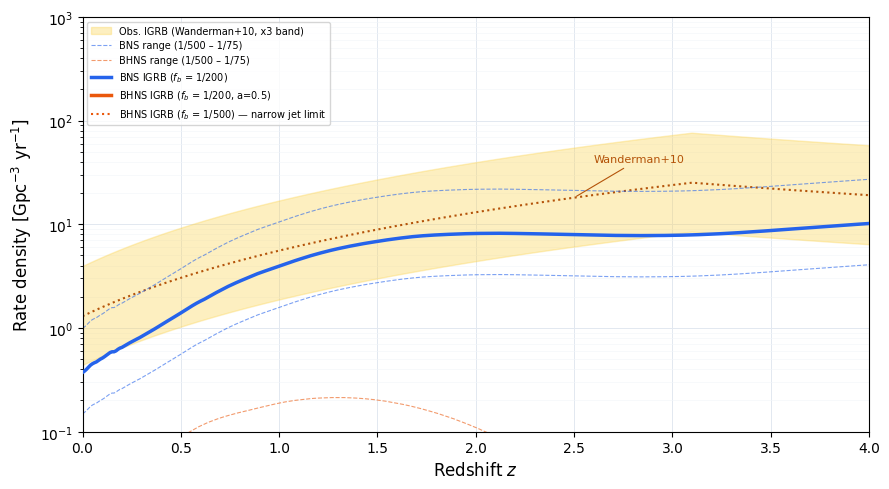

BNS  lGRB z=0 (fb=1/200):  0.37 Gpc^-3 yr^-1
BHNS lGRB z=0 (fb=1/200):  0.01 Gpc^-3 yr^-1
BHNS lGRB z=0 (fb=1/500):  0.00 Gpc^-3 yr^-1
Observed mid   z=0:         1.30 Gpc^-3 yr^-1
Observed range z=0:         0.43 - 3.90 Gpc^-3 yr^-1


In [31]:
# ── Beaming correction ────────────────────────────────────────────────────
# fb = 1 - cos(theta_jet).  Fiducial: theta_jet ~ 5.7 deg -> fb = 1/200.
# Range: fb_lo = 1/500, fb_hi = 1/75  (Fong+15, Berger 2014).
fb_fid = 1.0 / 200.0
fb_lo  = 1.0 / 500.0
fb_hi  = 1.0 / 75.0   # theta_jet ~ 11 deg, conservative upper limit

r_bns_long  = merger_rates_BNS['Long cbGRB']
r_bhns_long = merger_rates_BHNS['Long cbGRB (a=0.5)']

bns_fid   = r_bns_long  * fb_fid
bhns_fid  = r_bhns_long * fb_fid
bhns_cons = r_bhns_long * fb_lo    # conservative fb=1/500 line

bns_lo,  bns_hi  = r_bns_long  * fb_lo, r_bns_long  * fb_hi
bhns_lo, bhns_hi = r_bhns_long * fb_lo, r_bhns_long * fb_hi

# ── Observational lGRB rate density (Wanderman & Piran 2010) ─────────────
# Broken power-law: rho ~ (1+z)^2.1 for z<3.1, (1+z)^-1.4 for z>3.1
# Local rate rho_0 = 1.3 Gpc^-3 yr^-1; uncertainty factor x3.
# The x3 band is observational (folds in luminosity function systematics),
# not a statistical confidence interval -- see Wanderman & Piran 2010 Sec 4.2.
rho0   = 1.3
z_br   = 3.1
obs_mid = np.where(redshifts < z_br,
                   rho0 * (1 + redshifts)**2.1,
                   rho0 * (1 + z_br)**2.1 * ((1 + redshifts)/(1 + z_br))**(-1.4))
obs_lo  = obs_mid / 3.0
obs_hi  = obs_mid * 3.0

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

# Observational band
ax.fill_between(redshifts, obs_lo, obs_hi, color='#FCD34D', alpha=0.35, zorder=1,
                label='Obs. lGRB (Wanderman+10, x3 band)')
ax.plot(redshifts, obs_mid, color='#B45309', lw=1.5, ls=':', zorder=2)
# Direct label on the curve at z~1.5
iz = np.argmin(np.abs(redshifts - 2.5))
ax.annotate('Wanderman+10', xy=(redshifts[iz], obs_mid[iz]),
            xytext=(2.6, obs_mid[iz]*2.2), fontsize=8, color='#B45309',
            arrowprops=dict(arrowstyle='-', color='#B45309', lw=0.8))

# BNS beaming range: two thin dashed boundary lines, no fill
ax.plot(redshifts, bns_lo, color='#2563EB', lw=0.8, ls='--', alpha=0.6)
ax.plot(redshifts, bns_hi, color='#2563EB', lw=0.8, ls='--', alpha=0.6,
        label='BNS range (1/500 – 1/75)')

# BHNS beaming range: two thin dashed boundary lines, no fill
ax.plot(redshifts, bhns_lo, color='#EA580C', lw=0.8, ls='--', alpha=0.6)
ax.plot(redshifts, bhns_hi, color='#EA580C', lw=0.8, ls='--', alpha=0.6,
        label='BHNS range (1/500 – 1/75)')

# Fiducial lines
ax.plot(redshifts, bns_fid,  color='#2563EB', lw=2.5, ls='-',  zorder=3,
        label=r'BNS lGRB ($f_b$ = 1/200)')
ax.plot(redshifts, bhns_fid, color='#EA580C', lw=2.5, ls='-',  zorder=3,
        label=r'BHNS lGRB ($f_b$ = 1/200, a=0.5)')

# Conservative BHNS line: fb=1/500 — if this enters the obs band, it constrains spin
ax.plot(redshifts, bhns_cons, color='#EA580C', lw=1.5, ls=':',  zorder=3,
        label=r'BHNS lGRB ($f_b$ = 1/500) — narrow jet limit')

# Annotate where the narrow-jet line enters the observed band
iz2 = np.argmin(np.abs(redshifts - 1.4))
ax.annotate('narrow jet\nenters obs. band', xy=(redshifts[iz2], bhns_cons[iz2]),
            xytext=(1.6, 0.25), fontsize=7, color='#EA580C', style='italic',
            arrowprops=dict(arrowstyle='->', color='#EA580C', lw=0.8))

# Grid
ax.grid(which='major', color='#E2E8F0', linewidth=0.7, linestyle='-', zorder=0)
ax.grid(which='minor', color='#F1F5F9', linewidth=0.4, linestyle='-', zorder=0)
ax.set_axisbelow(True)

ax.set_xlim(0, 4)
ax.set_ylim(1e-1, 1e3)
ax.set_yscale('log')
ax.set_xlabel('Redshift $z$', fontsize=12)
ax.set_ylabel(r'Rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=12)
ax.legend(fontsize=7, loc='upper left')
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/Plots/rate_bns_bhns_dominance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"BNS  lGRB z=0 (fb=1/200):  {bns_fid[0]:.2f} Gpc^-3 yr^-1")
print(f"BHNS lGRB z=0 (fb=1/200):  {bhns_fid[0]:.2f} Gpc^-3 yr^-1")
print(f"BHNS lGRB z=0 (fb=1/500):  {bhns_cons[0]:.2f} Gpc^-3 yr^-1")
print(f"Observed mid   z=0:         {obs_mid[0]:.2f} Gpc^-3 yr^-1")
print(f"Observed range z=0:         {obs_lo[0]:.2f} - {obs_hi[0]:.2f} Gpc^-3 yr^-1")


## 12. BNS vs BHNS Dominance of Long cbGRB Channel

Which progenitor channel dominates long cbGRBs — and does it change with redshift?
BNS and BHNS long cbGRB rates sum to 100% at each z.
At low z, the higher BHNS formation efficiency (boosted by massive BH+NS systems) dominates.
At high z, low-metallicity environments preferentially increase BNS long cbGRB production,
driving a channel crossover.

Channel crossover at z = 9.80
z=0:  BNS 98.0%   BHNS 2.0%
z=1:  BNS 98.2%   BHNS 1.8%
z=3:  BNS 100.0%   BHNS 0.0%


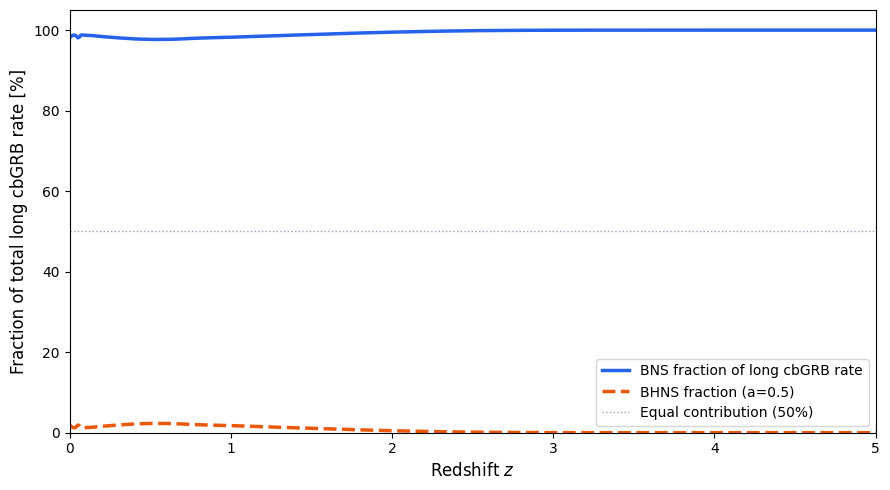

In [32]:
r_bns_long  = merger_rates_BNS['Long cbGRB']
r_bhns_long = merger_rates_BHNS['Long cbGRB (a=0.5)']

total_long = r_bns_long + r_bhns_long
safe_total = np.where(total_long > 0, total_long, np.nan)

frac_bns  = r_bns_long  / safe_total * 100
frac_bhns = r_bhns_long / safe_total * 100

# Find crossover redshift where BNS fraction crosses 50%
cross_idx = np.where(np.diff(np.sign(frac_bns - 50)))[0]
z_cross = redshifts[cross_idx[0]] if len(cross_idx) > 0 else None

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(redshifts, frac_bns,  color='#2563EB', lw=2.5, label='BNS fraction of long cbGRB rate')
ax.plot(redshifts, frac_bhns, color='#EA580C', lw=2.5, ls='--', label='BHNS fraction (a=0.5)')
ax.axhline(50, color='#94A3B8', lw=1, ls=':', label='Equal contribution (50%)')

# Annotate the crossover
if z_cross is not None:
    ax.axvline(z_cross, color='#94A3B8', lw=1, ls=':')
    ax.annotate(f'Crossover\nz = {z_cross:.2f}',
                xy=(z_cross, 50),
                xytext=(z_cross + 0.5, 22),
                fontsize=9, color='#475569',
                arrowprops=dict(arrowstyle='->', color='#475569', lw=1.0))
    print(f"Channel crossover at z = {z_cross:.2f}")

print(f"z=0:  BNS {frac_bns[0]:.1f}%   BHNS {frac_bhns[0]:.1f}%")
iz1 = np.argmin(np.abs(redshifts - 1.0))
print(f"z=1:  BNS {frac_bns[iz1]:.1f}%   BHNS {frac_bhns[iz1]:.1f}%")
iz3 = np.argmin(np.abs(redshifts - 3.0))
print(f"z=3:  BNS {frac_bns[iz3]:.1f}%   BHNS {frac_bhns[iz3]:.1f}%")

ax.set_xlim(0, 5)
ax.set_ylim(0, 105)
ax.set_xlabel('Redshift $z$', fontsize=12)
ax.set_ylabel('Fraction of total long cbGRB rate [%]', fontsize=12)
ax.legend(fontsize=10, loc='lower right')
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/Plots/rate_long_grb_channel_fraction.png', dpi=150, bbox_inches='tight')
plt.show()


## 13. GRB Channel Fraction vs Redshift

Which GRB type dominates the total merger-driven GRB rate at each epoch?

Fractions computed as R_class(z) / [R_BNS_short + R_BNS_long + R_BHNS_short + R_BHNS_long](z).
All four cbGRB channels are included.

Absolute rates [Gpc⁻³ yr⁻¹]:
   z     BNS Short    BNS Long    BHNS Short     BHNS Long
   0        1131.6        74.5         480.5           1.5
   1        6819.6       788.2        2450.4          14.2
   2        7354.9      1630.0        3089.9           8.2
   4        4713.6      2033.9         398.8           0.0
   6        2421.7      1437.7          52.6           0.0


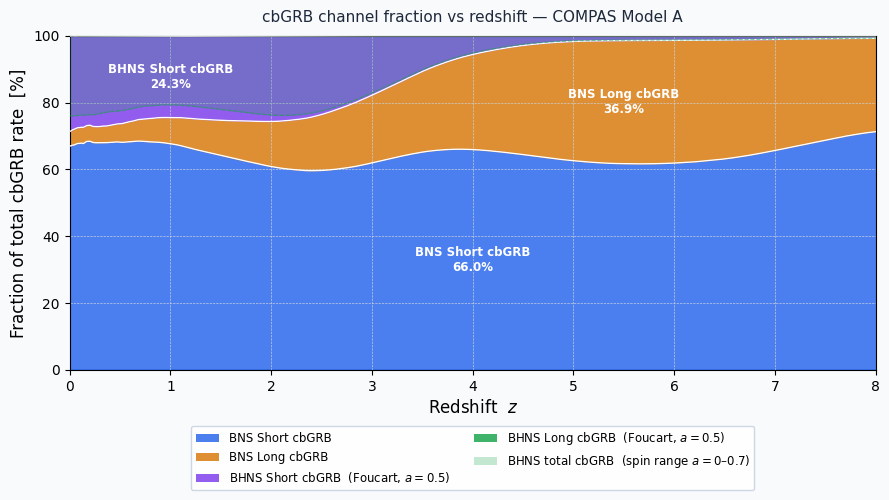


Fractions at key redshifts (fiducial a=0.5):
  z=0: BNS Short 67.0%  BNS Long 4.4%  BHNS Short 28.5%  BHNS Long 0.1%  (spin range: Short 4.5–33.8%  Long 0.0–10.9%)
  z=1: BNS Short 67.7%  BNS Long 7.8%  BHNS Short 24.3%  BHNS Long 0.1%  (spin range: Short 3.8–27.8%  Long 0.0–10.6%)
  z=2: BNS Short 60.9%  BNS Long 13.5%  BHNS Short 25.6%  BHNS Long 0.1%  (spin range: Short 1.9–31.0%  Long 0.0–8.6%)
  z=4: BNS Short 66.0%  BNS Long 28.5%  BHNS Short 5.6%  BHNS Long 0.0%  (spin range: Short 0.4–11.7%  Long 0.0–2.1%)
  z=6: BNS Short 61.9%  BNS Long 36.8%  BHNS Short 1.3%  BHNS Long 0.0%  (spin range: Short 0.1–3.7%  Long 0.0–0.5%)


In [33]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ── Rate arrays ───────────────────────────────────────────────────────────────
r_bns_short      = merger_rates_BNS['Short cbGRB']
r_bns_long       = merger_rates_BNS['Long cbGRB']
r_bhns_short_fid = merger_rates_BHNS['Short cbGRB (a=0.5)']   # fiducial spin
r_bhns_long_fid  = merger_rates_BHNS['Long cbGRB (a=0.5)']    # fiducial spin

# Compute spin sensitivity if not already in memory (requires Cell 12 + 14 to have run)
if 'merger_rates_BHNS_long_spin' not in dir():
    merger_rates_BHNS_long_spin  = {}
    merger_rates_BHNS_short_spin = {}
    for _a in [0.0, 0.7]:
        _disk_a  = foucart_disk_mass(BH, NS, a_BH=_a)
        _long_a  = (_disk_a >= 0.1)
        _short_a = (_disk_a >= 0.01) & (_disk_a < 0.1)
        merger_rates_BHNS_long_spin[_a] = compute_merger_rate(
            redshifts, times, time_first_SF, n_formed_BHNS, dPdlogZ, metallicities, p_draw,
            Z_BHNS[_long_a], delay_BHNS[_long_a], w_BHNS[_long_a],
        )
        merger_rates_BHNS_short_spin[_a] = compute_merger_rate(
            redshifts, times, time_first_SF, n_formed_BHNS, dPdlogZ, metallicities, p_draw,
            Z_BHNS[_short_a], delay_BHNS[_short_a], w_BHNS[_short_a],
        )
        print(f'  a={_a}: Long {_long_a.sum():,}  Short {_short_a.sum():,} systems'
              f'  z=0 Long: {merger_rates_BHNS_long_spin[_a][0]:.1f}'
              f'  Short: {merger_rates_BHNS_short_spin[_a][0]:.1f} Gpc\u207b\u00b3yr\u207b\u00b9')

r_bhns_long_lo  = merger_rates_BHNS_long_spin[0.0]
r_bhns_long_hi  = merger_rates_BHNS_long_spin[0.7]
r_bhns_short_lo = merger_rates_BHNS_short_spin[0.0]
r_bhns_short_hi = merger_rates_BHNS_short_spin[0.7]

# ── Sanity check: absolute rates ─────────────────────────────────────────────
z = redshifts
print("Absolute rates [Gpc\u207b\u00b3 yr\u207b\u00b9]:")
print(f"{'z':>4}  {'BNS Short':>12}  {'BNS Long':>10}  {'BHNS Short':>12}  {'BHNS Long':>12}")
for _zp in [0, 1, 2, 4, 6]:
    _i = np.argmin(np.abs(z - _zp))
    print(f"{_zp:>4}  {r_bns_short[_i]:>12.1f}  {r_bns_long[_i]:>10.1f}"
          f"  {r_bhns_short_fid[_i]:>12.1f}  {r_bhns_long_fid[_i]:>12.1f}")

# ── Fraction helper (4 channels) ─────────────────────────────────────────────
def _frac(r_s, r_l, r_bs, r_bl):
    tot = np.where((r_s + r_l + r_bs + r_bl) > 0,
                    r_s + r_l + r_bs + r_bl, np.nan)
    return r_s/tot*100, r_l/tot*100, r_bs/tot*100, r_bl/tot*100

f_short_fid, f_long_fid, f_bhs_fid, f_bhl_fid = _frac(
    r_bns_short, r_bns_long, r_bhns_short_fid, r_bhns_long_fid)
_, _, f_bhs_lo, f_bhl_lo = _frac(
    r_bns_short, r_bns_long, r_bhns_short_lo, r_bhns_long_lo)
_, _, f_bhs_hi, f_bhl_hi = _frac(
    r_bns_short, r_bns_long, r_bhns_short_hi, r_bhns_long_hi)

# Stacked boundaries: BNS Short | BNS Long | BHNS Short | BHNS Long
s1 = f_short_fid
s2 = s1 + f_long_fid
s3 = s2 + f_bhs_fid
s4 = s3 + f_bhl_fid

# BHNS combined (Short + Long) spin envelope for uncertainty band
bhns_tot_fid = f_bhs_fid + f_bhl_fid
bhns_tot_lo  = f_bhs_lo  + f_bhl_lo
bhns_tot_hi  = f_bhs_hi  + f_bhl_hi
s_top_lo = s2 + bhns_tot_lo
s_top_hi = s2 + bhns_tot_hi

# ── Colors ────────────────────────────────────────────────────────────────────
C_s  = '#2563EB'   # blue   — BNS Short
C_l  = '#D97706'   # amber  — BNS Long
C_bs = '#7C3AED'   # purple — BHNS Short
C_bl = '#16A34A'   # green  — BHNS Long

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5.2))
fig.patch.set_facecolor('#F8FAFC')
ax.set_facecolor('#F8FAFC')

# Solid filled bands
ax.fill_between(z, 0,  s1, color=C_s,  alpha=0.82)
ax.fill_between(z, s1, s2, color=C_l,  alpha=0.82)
ax.fill_between(z, s2, s3, color=C_bs, alpha=0.82)
ax.fill_between(z, s3, s4, color=C_bl, alpha=0.82)

# BHNS spin uncertainty band on the top edge (combined BHNS envelope)
ax.fill_between(z, s_top_lo, s_top_hi, color=C_bl, alpha=0.22, zorder=4)

# White band boundaries
ax.plot(z, s1, color='white', lw=1.0, zorder=5)
ax.plot(z, s2, color='white', lw=1.0, zorder=5)
ax.plot(z, s3, color='white', lw=0.7, zorder=5)

# Dashed BHNS spin bound lines
ax.plot(z, s_top_lo, color=C_bl, lw=0.8, ls='--', alpha=0.55, zorder=5)
ax.plot(z, s_top_hi, color=C_bl, lw=0.8, ls='--', alpha=0.55, zorder=5)

_z_max = 8.0
ax.set_xlim(z.min(), _z_max)
ax.set_ylim(0, 100)
ax.set_xlabel('Redshift  $z$', fontsize=12)
ax.set_ylabel('Fraction of total cbGRB rate  [%]', fontsize=12)
ax.set_title(r'cbGRB channel fraction vs redshift — COMPAS Model A',
             fontsize=11, color='#1E293B', pad=10)

ax.grid(True, which='major', color='#CBD5E1', linewidth=0.45, linestyle='--', zorder=0)
ax.tick_params(labelsize=10)

# In-band labels at z where each band is widest
_label_min = 4.0
for _z_a, _bot_arr, _top_arr, _frac_arr, _lbl in [
    (4.0, np.zeros_like(s1), s1, f_short_fid, 'BNS Short cbGRB'),
    (5.5, s1,                s2, f_long_fid,  'BNS Long cbGRB'),
    (1.0, s2,                s3, f_bhs_fid,   'BHNS Short cbGRB'),
    (1.0, s3,                s4, f_bhl_fid,   'BHNS Long cbGRB'),
]:
    _iz = np.argmin(np.abs(z - _z_a))
    _bot, _top = _bot_arr[_iz], _top_arr[_iz]
    if (_top - _bot) < _label_min:
        continue
    ax.text(_z_a, (_bot + _top) / 2,
            f'{_lbl}\n{_frac_arr[_iz]:.1f}%',
            ha='center', va='center',
            fontsize=8.5, color='white', fontweight='bold', zorder=6)


# 2-column legend below plot
legend_handles = [
    Patch(facecolor=C_s,  alpha=0.82, label='BNS Short cbGRB'),
    Patch(facecolor=C_l,  alpha=0.82, label='BNS Long cbGRB'),
    Patch(facecolor=C_bs, alpha=0.82, label=r'BHNS Short cbGRB  (Foucart, $a=0.5$)'),
    Patch(facecolor=C_bl, alpha=0.82, label=r'BHNS Long cbGRB  (Foucart, $a=0.5$)'),
    Patch(facecolor=C_bl, alpha=0.25, label=r'BHNS total cbGRB  (spin range $a=0$–$0.7$)'),
]
ax.legend(handles=legend_handles, fontsize=8.5, framealpha=0.93,
          edgecolor='#CBD5E1', loc='upper center',
          bbox_to_anchor=(0.5, -0.15), ncol=2)

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/Plots/grb_channel_fraction_vs_redshift.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

print("\nFractions at key redshifts (fiducial a=0.5):")
for _zp in [0, 1, 2, 4, 6]:
    _i = np.argmin(np.abs(z - _zp))
    print(f"  z={_zp}: BNS Short {f_short_fid[_i]:.1f}%  BNS Long {f_long_fid[_i]:.1f}%"
          f"  BHNS Short {f_bhs_fid[_i]:.1f}%  BHNS Long {f_bhl_fid[_i]:.1f}%"
          f"  (spin range: Short {f_bhs_lo[_i]:.1f}–{f_bhs_hi[_i]:.1f}%  Long {f_bhl_lo[_i]:.1f}–{f_bhl_hi[_i]:.1f}%)")


## 9. Export

In [34]:
np.save('/Users/josephrodriguez/research visualization/results/rates_BNS.npy',
        np.array([redshifts,
                  merger_rates_BNS['All BNS'],
                  merger_rates_BNS['Short cbGRB'],
                  merger_rates_BNS['Long cbGRB']]))

np.save('/Users/josephrodriguez/research visualization/results/rates_BHNS.npy',
        np.array([redshifts,
                  merger_rates_BHNS['All BHNS'],
                  merger_rates_BHNS['Long cbGRB (a=0.5)']]))

print("Rates saved to rates_BNS.npy and rates_BHNS.npy")

Rates saved to rates_BNS.npy and rates_BHNS.npy
